In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Wczytanie przetworzonych danych
file_path = 'transformed_flight_data.parquet'
df = pd.read_parquet(file_path)

# 2. Wyświetlenie podstawowych informacji o nowym zbiorze
print(f"Załadowano zbiór o rozmiarze: {df.shape[0]} wierszy i {df.shape[1]} kolumn.")
print("\nPodgląd pierwszych wierszy:")
display(df.head())

# 3. Sprawdzenie, czy kolumny Targetowe (cele) są gotowe
# (Jeśli ich jeszcze nie ma, poniżej przypomnienie jak je wygenerować dla BAGGAGE)
if 'TARGET_BAGGAGE' not in df.columns:
    print("\n[INFO]: Kolumny targetowe nie zostały wykryte. Generowanie...")
    # Tutaj możesz wstawić funkcję wyciągającą 'sold' z EMD_INFO_LIST, którą omawialiśmy

Załadowano zbiór o rozmiarze: 527947 wierszy i 36 kolumn.

Podgląd pierwszych wierszy:


,OND,MARKET,LANGUAGE,segments,recommendations,emds_order,TRIP_START_DATE,SALES_DATE,FLIGHT_TYPE,DTD,...,HAS_CHILDREN_OR_INFANTS,TRIP_MONTH,TRIP_DAY_OF_WEEK,IS_WEEKEND_FLIGHT,TRIP_QUARTER,NUMBER_OF_SEGMENTS,IS_DIRECT_FLIGHT,TOTAL_EMD_SPEND,TOTAL_REVENUE,BOOKING_WINDOW
0,CEG-CAJ,GREAT MERIDIAN,LANG_03,"[{""ORIGIN_AIRPORT_CODE"":""CEG"",""DESTINATION_AIR...","[""""]","[""MEAL"",""FAST TRACK"",""BAGGAGE"",""SPECIAL EQUIPM...",2038-01-31,2037-11-06,Round-Trip,85.0,...,0,1,6,1,1,2,0,0.0,67.481235,Advance (31-90)
1,CAJ-BIF,SOUTH MERIDIAN,LANG_09,"[{""ORIGIN_AIRPORT_CODE"":""CAJ"",""DESTINATION_AIR...","[""""]","[""BUSINESS LOUNGE"",""FAST TRACK"",""PET"",""BAGGAGE...",2038-02-04,2038-01-25,Round-Trip,9.0,...,0,2,3,0,1,2,0,0.0,23.655009,Short (8-14)
2,CEW-BIW,GREAT AURORA,LANG_10,"[{""ORIGIN_AIRPORT_CODE"":""CEW"",""DESTINATION_AIR...","[""""]","[""BAGGAGE"",""MEAL"",""FAST TRACK"",""BUSINESS LOUNG...",2038-01-02,2037-12-06,One-Way,27.0,...,0,1,5,1,1,2,0,0.0,13.614800,Medium (15-30)
3,BIC-CAJ,UPPER APEX,LANG_09,"[{""ORIGIN_AIRPORT_CODE"":""BIC"",""DESTINATION_AIR...","[""""]","[""MEAL"",""FAST TRACK"",""BAGGAGE"",""SPECIAL EQUIPM...",2037-11-16,2037-10-28,Round-Trip,18.0,...,0,11,0,0,4,2,0,0.0,88.344584,Medium (15-30)
4,CUN-CAJ,NORTH HORIZON,LANG_04,"[{""ORIGIN_AIRPORT_CODE"":""CUN"",""DESTINATION_AIR...","[""""]","[""PET"",""BAGGAGE"",""MEAL"",""SPECIAL EQUIPMENT"",""B...",2038-02-21,2038-01-27,Round-Trip,24.0,...,0,2,6,1,1,2,0,0.0,33.183399,Medium (15-30)



[INFO]: Kolumny targetowe nie zostały wykryte. Generowanie...


In [3]:
import json

# 1. Funkcja sprawdzająca czy usługa została kupiona
def get_target_for_service(emd_val, target_service_name):
    # Obsługa pustych wartości
    if pd.isna(emd_val) or emd_val == "" or emd_val == '[""]':
        return 0
        
    # Sprawdzamy czy wartość to nadal tekst (JSON) czy już sparsowana lista
    if isinstance(emd_val, str):
        try:
            emd_list = json.loads(emd_val)
        except (json.JSONDecodeError, TypeError):
            return 0
    elif isinstance(emd_val, list):
        emd_list = emd_val
    else:
        return 0
        
    # Szukamy konkretnej usługi w liście
    for item in emd_list:
        if isinstance(item, dict) and item.get('emd_name') == target_service_name:
            if str(item.get('sold')).lower() == 'true':
                return 1
    return 0

# 2. Wygenerowanie brakującej kolumny TARGET_BAGGAGE bazując na kolumnie EMD_INFO
print("Generowanie brakującej kolumny TARGET_BAGGAGE...")
df['TARGET_BAGGAGE'] = df['EMD_INFO'].apply(lambda x: get_target_for_service(x, 'BAGGAGE'))

print("\nSukces! Kolumna dodana. Oto podsumowanie klas:")
print(df['TARGET_BAGGAGE'].value_counts())

Generowanie brakującej kolumny TARGET_BAGGAGE...

Sukces! Kolumna dodana. Oto podsumowanie klas:
TARGET_BAGGAGE
0    501655
1     26292
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

print("1. Przygotowanie cech (Features)...")
# Wybieramy najważniejsze kolumny do nauki
features_numeric = ['CALCULATED_DTD', 'TOTAL_PASSENGERS', 'HAS_CHILDREN_OR_INFANTS', 
                    'IS_WEEKEND_FLIGHT', 'IS_DIRECT_FLIGHT', 'TRIP_MONTH']
features_categorical = ['FLIGHT_TYPE', 'FIRST_TOUCH_CHANNEL']

# Bierzemy tylko te dane i usuwamy puste wiersze, żeby model się nie zawiesił
df_model = df[features_numeric + features_categorical + ['TARGET_BAGGAGE']].dropna()

# Zamiana kolumn tekstowych na "zera i jedynki" (One-Hot Encoding)
X = pd.get_dummies(df_model[features_numeric + features_categorical], drop_first=True)
y = df_model['TARGET_BAGGAGE']

# Podział na zbiór treningowy (do nauki modelu) i testowy (do sprawdzenia jak mu poszło)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dane gotowe! Zbiór treningowy: {X_train.shape[0]} wierszy. Zbiór testowy: {X_test.shape[0]} wierszy.")

1. Przygotowanie cech (Features)...
Dane gotowe! Zbiór treningowy: 422357 wierszy. Zbiór testowy: 105590 wierszy.


In [5]:
from sklearn.ensemble import RandomForestClassifier

print("2. Rozpoczynam trening modelu (Random Forest)...")
# Ustawiamy class_weight='balanced', by model mocniej karał się za przeoczenie klienta kupującego bagaż
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)

# Uczymy model na danych treningowych
rf_model.fit(X_train, y_train)

print("Trening zakończony! Model jest gotowy do przewidywań.")

2. Rozpoczynam trening modelu (Random Forest)...
Trening zakończony! Model jest gotowy do przewidywań.


3. Ocena skuteczności modelu na danych testowych...

[Raport Klasyfikacji]:
                     precision    recall  f1-score   support

Nie Kupi Bagażu (0)       0.98      0.69      0.81    100332
     Kupi Bagaż (1)       0.10      0.69      0.18      5258

           accuracy                           0.69    105590
          macro avg       0.54      0.69      0.50    105590
       weighted avg       0.93      0.69      0.78    105590



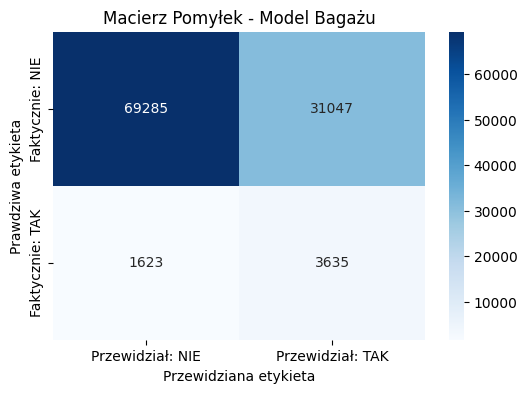

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("3. Ocena skuteczności modelu na danych testowych...")
# Robimy przewidywania na danych, których model nigdy wcześniej nie widział
y_pred = rf_model.predict(X_test)

# Raport z metrykami Precision, Recall i F1-Score
print("\n[Raport Klasyfikacji]:")
print(classification_report(y_test, y_pred, target_names=['Nie Kupi Bagażu (0)', 'Kupi Bagaż (1)']))

# Rysowanie Macierzy Pomyłek (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Przewidział: NIE', 'Przewidział: TAK'], yticklabels=['Faktycznie: NIE', 'Faktycznie: TAK'])
plt.title('Macierz Pomyłek - Model Bagażu')
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

4. Analiza Ważności Cech (Feature Importance)...


/var/folders/fq/6pwh8dhn12s2vc5_6nyn5t2c0000gn/T/ipykernel_3610/2002303637.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ważność', y='Cecha', data=fi_df.head(10), palette='viridis')


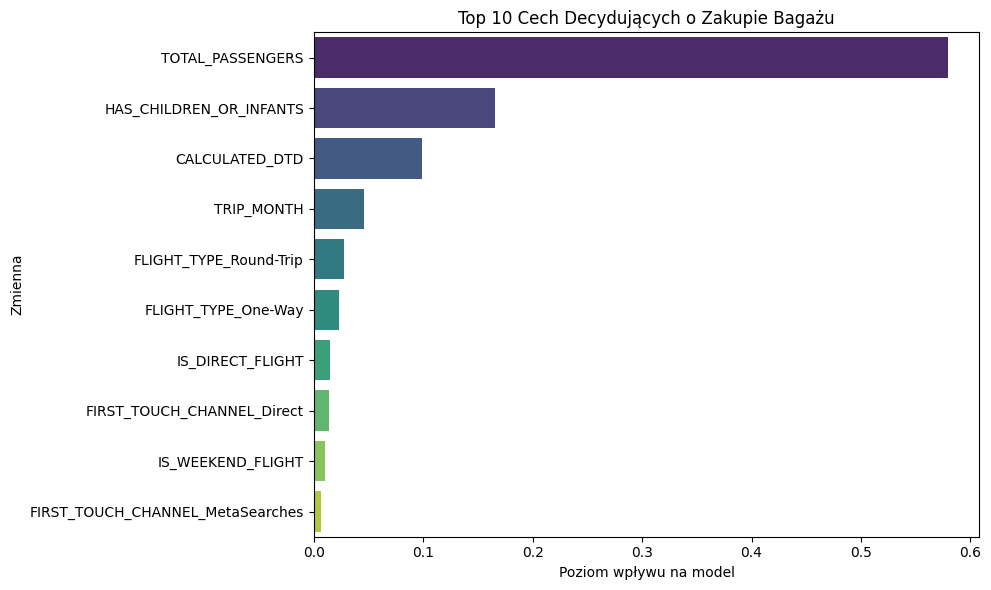

In [7]:
print("4. Analiza Ważności Cech (Feature Importance)...")

# Pobieranie ważności z modelu
importances = rf_model.feature_importances_
feature_names = X.columns

# Tworzenie ramki danych dla łatwego sortowania i rysowania
fi_df = pd.DataFrame({'Cecha': feature_names, 'Ważność': importances})
fi_df = fi_df.sort_values(by='Ważność', ascending=False)

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
sns.barplot(x='Ważność', y='Cecha', data=fi_df.head(10), palette='viridis')
plt.title('Top 10 Cech Decydujących o Zakupie Bagażu')
plt.xlabel('Poziom wpływu na model')
plt.ylabel('Zmienna')
plt.tight_layout()
plt.show()